# Machine learning foundations: overfitting and how to catch it

Every model is a trade-off. Too simple and it misses the pattern
(**underfitting**). Too flexible and it memorises the noise in the training
data (**overfitting**). Both fail on new data, which is the only data that
matters.

This notebook builds that intuition with a problem small enough to see:

1. Fitting curves of increasing flexibility
2. Why training error lies, and test error doesn't
3. Cross-validation: choosing complexity without touching the test set
4. Regularisation: keeping a flexible model in check
5. Learning curves: will more data help?
6. Data leakage: how to get over 80% accuracy on pure noise (and how not to)

The data is simulated so we know the true pattern.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

rng = np.random.default_rng(2)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})


def true_pattern(x):
    return np.sin(1.5 * x) + 0.3 * x


def make_data(n):
    x = rng.uniform(-3, 3, n)
    return x.reshape(-1, 1), true_pattern(x) + rng.normal(0, 0.4, n)


X, y = make_data(30)
X_test, y_test = make_data(2000)  # a big "future" to measure honest error
grid = np.linspace(-3, 3, 300).reshape(-1, 1)

## 1. Three models, three outcomes

A polynomial's degree controls its flexibility. Degree 1 is a straight line;
degree 15 can wiggle through almost any set of points.

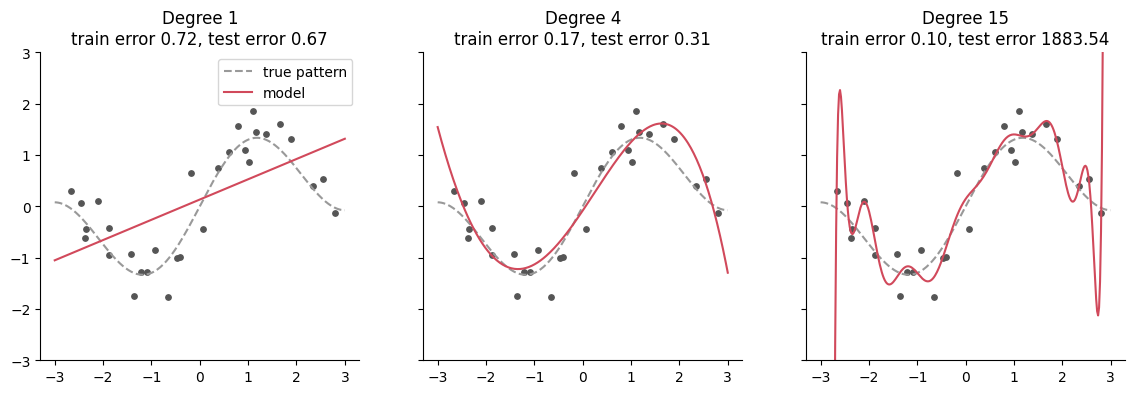

In [ ]:
def poly_model(degree, alpha=None):
    final = LinearRegression() if alpha is None else Ridge(alpha=alpha)
    return make_pipeline(PolynomialFeatures(degree, include_bias=False), StandardScaler(), final)


fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, degree in zip(axes, [1, 4, 15], strict=True):
    model = poly_model(degree).fit(X, y)
    train_err = mean_squared_error(y, model.predict(X))
    test_err = mean_squared_error(y_test, model.predict(X_test))
    ax.scatter(X, y, s=15, color="#555")
    ax.plot(grid, true_pattern(grid), "--", color="#999", label="true pattern")
    ax.plot(grid, model.predict(grid), color="#d1495b", label="model")
    ax.set(title=f"Degree {degree}\ntrain error {train_err:.2f}, test error {test_err:.2f}", ylim=(-3, 3))
axes[0].legend();

- **Degree 1** can't bend, so it misses the pattern on training *and* test
  data. That's high bias.
- **Degree 4** follows the real shape and ignores the noise.
- **Degree 15** has the lowest training error of all, because it chases
  individual points, and the highest test error. That's high variance.

The lesson: **training error always rewards complexity**, so it can never be
used to choose a model.

## 2. The U-shaped curve

Sweep the degree and track both errors.

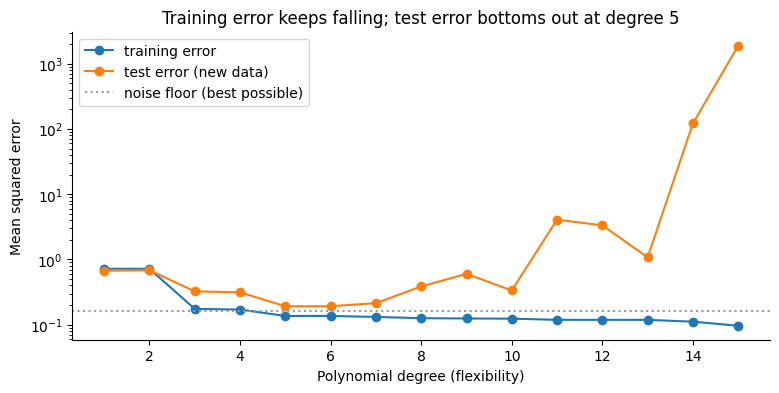

In [ ]:
degrees = range(1, 16)
train_errs, test_errs = [], []
for d in degrees:
    m = poly_model(d).fit(X, y)
    train_errs.append(mean_squared_error(y, m.predict(X)))
    test_errs.append(mean_squared_error(y_test, m.predict(X_test)))

best_degree = degrees[int(np.argmin(test_errs))]
fig, ax = plt.subplots()
ax.plot(degrees, train_errs, "o-", label="training error")
ax.plot(degrees, test_errs, "o-", label="test error (new data)")
ax.axhline(0.4 ** 2, color="#999", linestyle=":", label="noise floor (best possible)")
ax.set(yscale="log", xlabel="Polynomial degree (flexibility)", ylabel="Mean squared error",
       title=f"Training error keeps falling; test error bottoms out at degree {best_degree}")
ax.legend();

Training error falls forever. Test error falls, bottoms out, then climbs.
The dotted line is the noise we added: no model can beat it, and a model
whose training error drops *below* it is memorising noise.

## 3. Cross-validation: choosing without cheating

In real life we don't have 2,000 extra points to test on. If we picked the
degree using our test set, the test set would stop being a fair test.

**K-fold cross-validation** fixes this using only the training data. Split it
into 5 parts, train on 4, score on the 5th, rotate, and average. Each point
gets used for scoring exactly once.

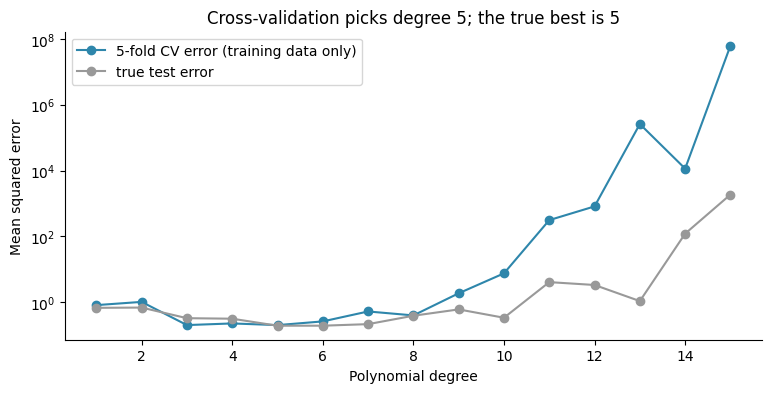

In [ ]:
folds = KFold(n_splits=5, shuffle=True, random_state=0)
cv_errs = [-cross_val_score(poly_model(d), X, y, cv=folds, scoring="neg_mean_squared_error").mean()
           for d in degrees]
cv_choice = degrees[int(np.argmin(cv_errs))]

fig, ax = plt.subplots()
ax.plot(degrees, cv_errs, "o-", color="#2e86ab", label="5-fold CV error (training data only)")
ax.plot(degrees, test_errs, "o-", color="#999", label="true test error")
ax.set(yscale="log", xlabel="Polynomial degree", ylabel="Mean squared error",
       title=f"Cross-validation picks degree {cv_choice}; the true best is {best_degree}")
ax.legend();

Cross-validation found a degree in the right place without ever seeing the
test data. With only 30 points it won't always land exactly on the best,
but it reliably avoids the disasters at both ends. This is the standard way to choose any setting,
from tree depth to learning rate.

## 4. Regularisation: flexibility with a leash

Instead of choosing a simpler model, we can keep the flexible one and
penalise large coefficients. **Ridge** regression adds `alpha × (sum of
squared coefficients)` to the error it minimises. A bigger alpha means a
smoother curve.

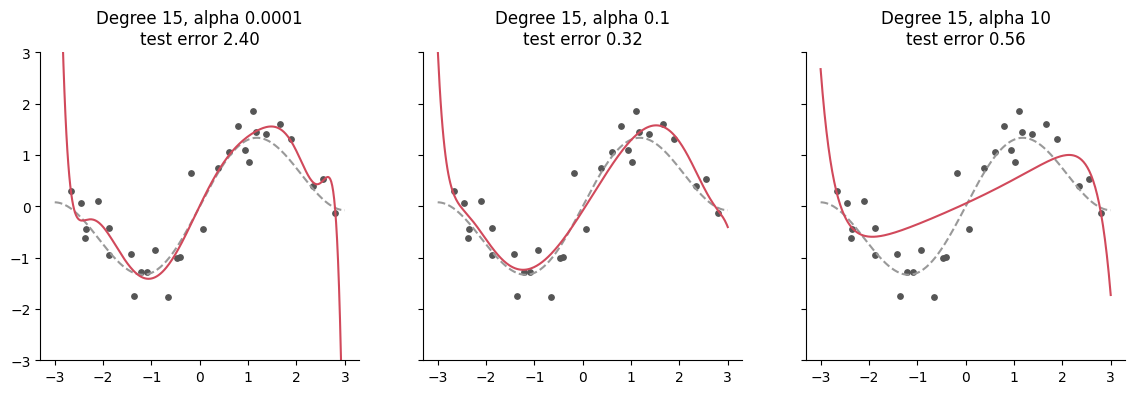

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, alpha in zip(axes, [0.0001, 0.1, 10], strict=True):
    m = poly_model(15, alpha=alpha).fit(X, y)
    test_err = mean_squared_error(y_test, m.predict(X_test))
    ax.scatter(X, y, s=15, color="#555")
    ax.plot(grid, true_pattern(grid), "--", color="#999")
    ax.plot(grid, m.predict(grid), color="#d1495b")
    ax.set(title=f"Degree 15, alpha {alpha}\ntest error {test_err:.2f}", ylim=(-3, 3))

A tiny alpha still overfits; a large one flattens the curve into
underfitting; the middle tames all 15 degrees of freedom. In practice you
pick alpha with cross-validation, exactly as we picked the degree.

Regularisation shows up everywhere under different names: L1/L2 penalties in
linear models, dropout and weight decay in neural networks, minimum leaf size
and learning rate in tree ensembles. Same idea each time.

## 5. Learning curves: will more data help?

Before spending money on more data, plot how the model's errors change as
the training set grows.

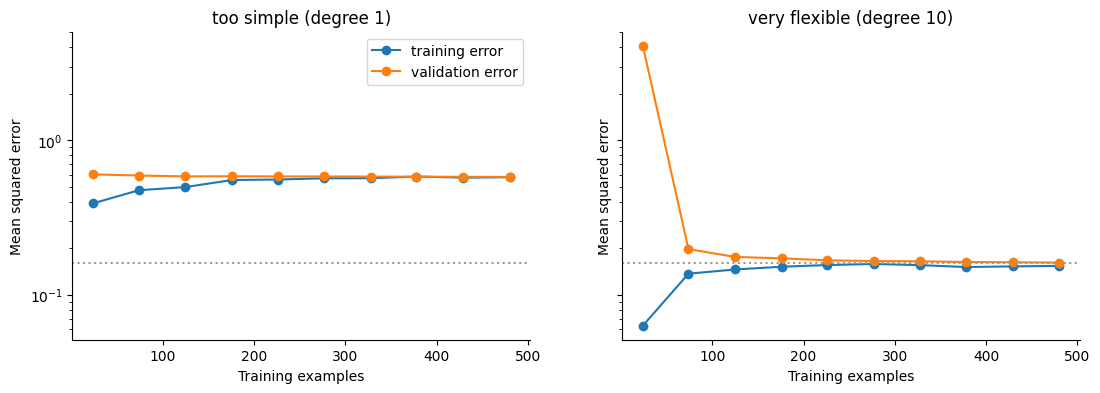

In [ ]:
X_big, y_big = make_data(600)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (degree, label) in zip(axes, [(1, "too simple (degree 1)"), (10, "very flexible (degree 10)")],
                               strict=True):
    sizes, train_scores, val_scores = learning_curve(
        poly_model(degree), X_big, y_big, cv=folds, scoring="neg_mean_squared_error",
        train_sizes=np.linspace(0.05, 1, 10))
    ax.plot(sizes, -train_scores.mean(axis=1), "o-", label="training error")
    ax.plot(sizes, -val_scores.mean(axis=1), "o-", label="validation error")
    ax.axhline(0.4 ** 2, color="#999", linestyle=":")
    ax.set(title=label, xlabel="Training examples", ylabel="Mean squared error", yscale="log")
axes[0].legend();

- **Too simple:** both curves meet quickly at a high error. More data won't
  help; you need a better model or better features.
- **Very flexible:** a big gap at first (overfitting) that closes as data
  grows. More data helps this model a lot.

## 6. Data leakage: over 80% accuracy on pure noise

Leakage is when information from outside the training set sneaks into
training. It produces brilliant validation scores and a model that fails in
production.

Here's a classic version. We make 100 "patients" with 5,000 random features
and **random labels**. Nothing can be predicted, so honest accuracy is 50%.

In [ ]:
X_noise = rng.normal(size=(100, 5000))
y_noise = rng.integers(0, 2, 100)

# Wrong: pick the 20 "best" features using ALL the data, then cross-validate.
best_features = SelectKBest(f_classif, k=20).fit(X_noise, y_noise).get_support()
leaky = cross_val_score(LogisticRegression(max_iter=1000), X_noise[:, best_features], y_noise, cv=folds)

# Right: feature selection is part of the model, so it's redone inside each fold.
honest_model = make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=1000))
honest = cross_val_score(honest_model, X_noise, y_noise, cv=folds)

print(f"Leaky cross-validation accuracy:  {leaky.mean():.0%}")
print(f"Honest cross-validation accuracy: {honest.mean():.0%}")

Leaky cross-validation accuracy:  83%
Honest cross-validation accuracy: 55%


The leaky version chose features that happened to line up with the labels,
*including the labels of the validation folds*, so of course it scored well.
The honest version repeats the selection inside each fold and correctly finds
nothing.

The rule: **anything that learns from data belongs inside the pipeline.**
That means scaling, imputing missing values, selecting features and encoding
categories. Other common leaks:

- A column that's only known after the outcome (a refund recorded after a
  cancellation; see the SaaS churn notebook).
- Random splits on time series, which let the model peek at the future.
- The same customer appearing in both training and test rows.

## Takeaways

- Training error always favours complexity. Judge models on unseen data.
- Use cross-validation to choose settings; touch the test set once, at the end.
- Regularisation lets you keep a flexible model without the overfitting.
- Learning curves tell you whether to get more data or a better model.
- Validation scores that look too good usually are. Hunt for leakage.